In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import datetime as dt

### 1. Construccion del portafolio con datos reales

In [14]:
stocks = ["JPM","^MXX","PLTR","V"]
weights = np.array([0.26,0.24,0.20,0.30])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*3)

In [15]:
prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

C:\Users\marce\AppData\Local\Temp\ipykernel_19480\2018562991.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]


Media diaria retornos:
Ticker
JPM     0.001221
PLTR    0.004379
V       0.000579
^MXX    0.000421
dtype: float64
\nMatriz de covarianza:
Ticker       JPM      PLTR         V      ^MXX
Ticker                                        
JPM     0.000213  0.000194  0.000082  0.000033
PLTR    0.000194  0.001660  0.000123  0.000090
V       0.000082  0.000123  0.000139  0.000020
^MXX    0.000033  0.000090  0.000020  0.000089


C:\Users\marce\AppData\Local\Temp\ipykernel_19480\2018562991.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


### 2. exploracion de datos del portafolio

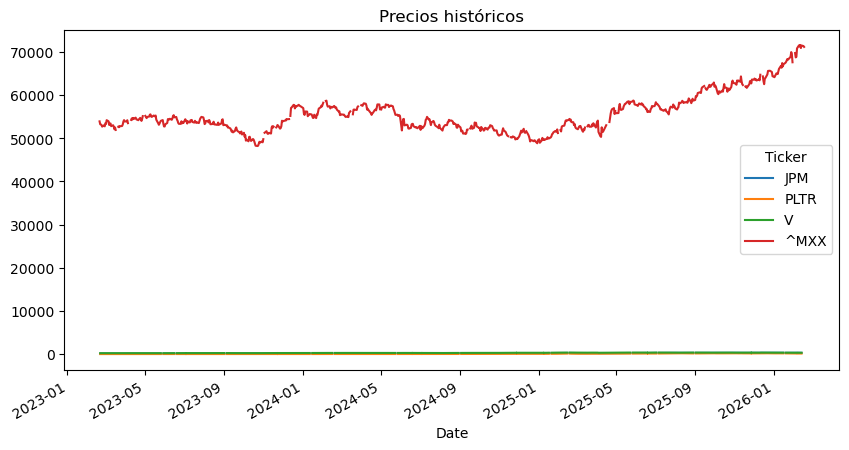

In [16]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()

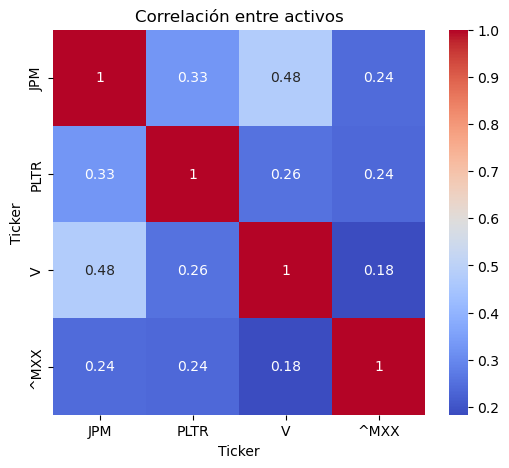

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

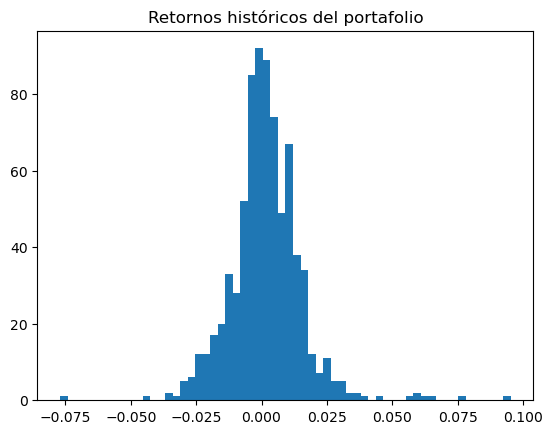

Volatilidad histórica diaria: 0.01373625971698224
Retornos históricos diaria: 0.001610583815759707


In [ ]:
portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()

print("Volatilidad histórica diaria:", portfolio_hist.std())
print("Retornos histórica diaria:", portfolio_hist.mean())



¿Qué activos están más correlacionados?

La correlacion mas alta es JP Morgan y Visa lo cual tiene sentido ya que estan en el sector financiero 


¿El portafolio parece estable o muy variable?

Parece bastante estable, el hecho que tengamos indices nos distribuye un poco mas el portafolio

¿Cuál activo parece dominar el comportamiento del portafolio?

Palantir tiene mas retornos diarios que las demas empresas
___

### 4. Analisis de la simulacion

In [19]:
num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))

In [20]:
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

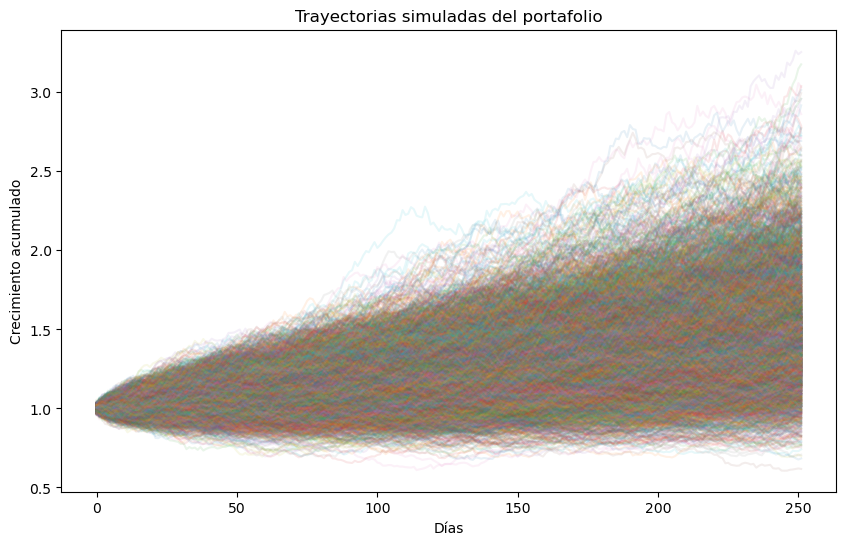

In [21]:
plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

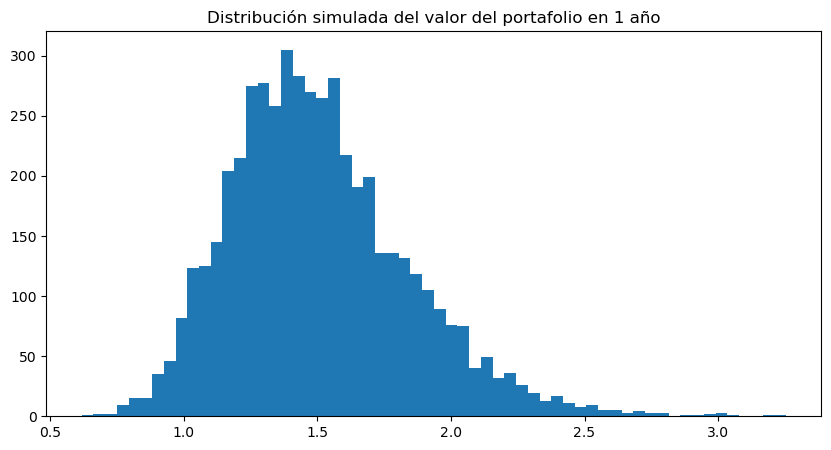

Valor esperado final: 1.5056318666904367
Probabilidad de pérdida: 0.0368
Valor maximo observado: 3.254686947470201
Valor minimo observado: 0.6173493937995969


In [23]:
final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))
print("Valor maximo observado:", final_values.max())
print("Valor minimo observado:", final_values.min())


### 5. Exploracion Libre 

In [ ]:
stocks = ["JPM","^MXX","PLTR","V"]
weights = np.array([0.26,0.24,0.20,0.30])

if not np.isclose(weights.sum(),1):
    raise ValueError("Los pesos deben sumar 1")

end = dt.datetime.now()
start = end - dt.timedelta(days=365*10)

prices = yf.download(stocks,start=start,end=end,progress=False)["Close"]
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
cov_matrix = returns.cov()

print("Media diaria retornos:")
print(mean_returns)
print("\\nMatriz de covarianza:")
print(cov_matrix)

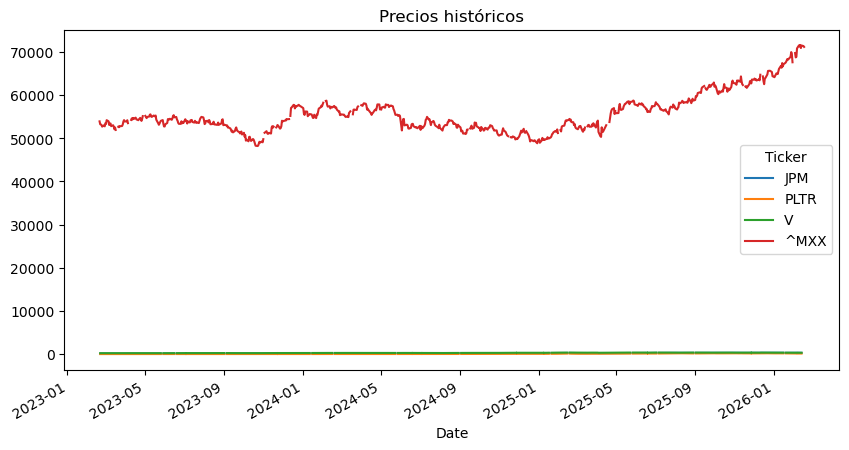

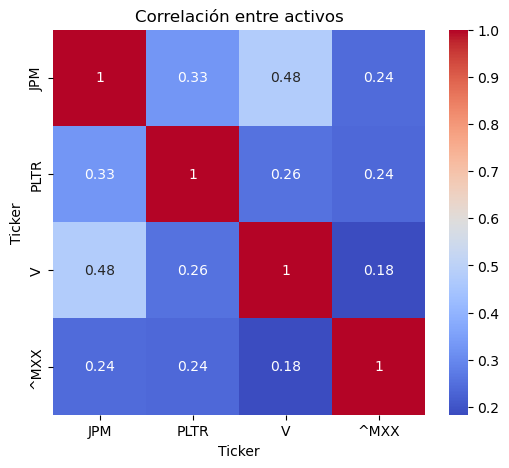

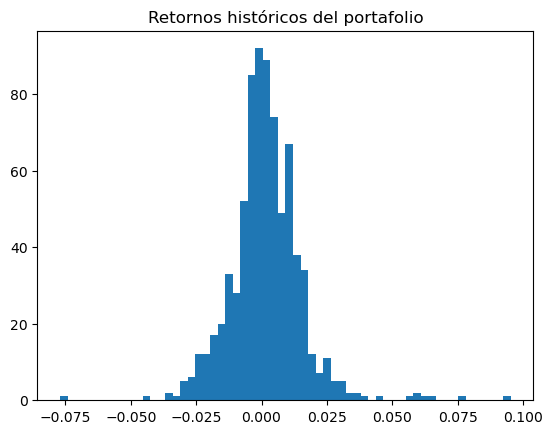

Volatilidad histórica diaria: 0.01373625971698224
Retornos históricos diaria: 0.001610583815759707


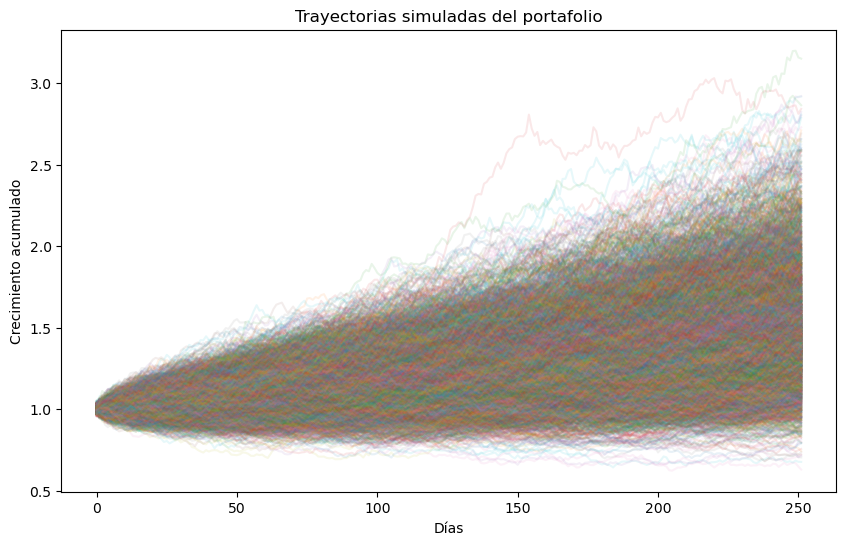

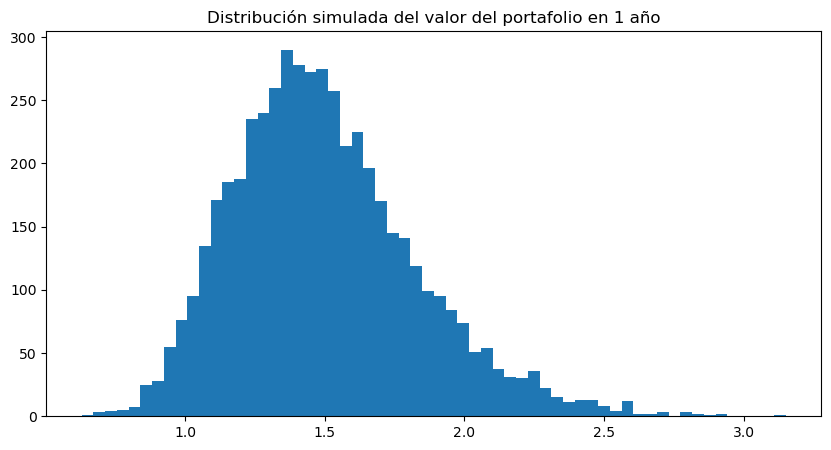

Valor esperado final: 1.4988852108020265
Probabilidad de pérdida: 0.0378
Valor maximo observado: 3.15110004654515
Valor minimo observado: 0.6297881884434389


In [24]:
prices.plot(figsize=(10,5),title="Precios históricos")
plt.show()
plt.figure(figsize=(6,5))

sns.heatmap(returns.corr(),annot=True,cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()

portfolio_hist = returns.dot(weights)

plt.hist(portfolio_hist,bins=60)
plt.title("Retornos históricos del portafolio")
plt.show()
print("Volatilidad histórica diaria:", portfolio_hist.std())
print("Retornos históricos diaria:", portfolio_hist.mean())

num_sim = 5000
num_days = 252
k = len(stocks)

L = np.linalg.cholesky(cov_matrix)
portfolio_paths = np.zeros((num_days,num_sim))
for m in range(num_sim):

    Z = np.random.normal(size=(num_days,k))
    correlated = Z @ L.T
    daily_returns = correlated + mean_returns.values
    port_daily = daily_returns @ weights
    portfolio_paths[:,m] = np.cumprod(1+port_daily)

plt.figure(figsize=(10,6))
plt.plot(portfolio_paths,alpha=0.1)
plt.title("Trayectorias simuladas del portafolio")
plt.xlabel("Días")
plt.ylabel("Crecimiento acumulado")
plt.show()

final_values = portfolio_paths[-1]

plt.figure(figsize=(10,5))
plt.hist(final_values,bins=60)
plt.title("Distribución simulada del valor del portafolio en 1 año")
plt.show()

print("Valor esperado final:", final_values.mean())
print("Probabilidad de pérdida:", np.mean(final_values<1))
print("Valor maximo observado:", final_values.max())
print("Valor minimo observado:", final_values.min())


le cambie el tiempo a 10 años, veo resultados muy similares y no vi mucha diferencia en el rendimiento yo volatilidad diaria lo cual me impresiono pero fue a ojo, una prueba estadistica seria mejor herramienta para comparar si son las mismas volatilidades y rendimientos